# Reproduction: A systematic color correction pipeline for controlled-environment imaging

**Paper:** *A systematic color correction pipeline for controlled‐environment imaging* — Plant Phenome Journal 9(1):e70067 (2026), DOI [10.1002/ppj2.70067](https://doi.org/10.1002/ppj2.70067) (open access; the publisher blocked agent full-text access, so scientific parameters below come from the **pinned author code**, not the paper PDF).

**Author code (used as-is):** [`collinswakholi/cc_test_pipeline`](https://github.com/collinswakholi/cc_test_pipeline) @ commit `42bb4aa11a5d6bdf09e1f9dfac8c184f38e7dc52` — pipeline class `ColorCorrection.py`, functions in `key_functions.py`, configuration in `kwargs.py`, flat-field module `FFC/FF_correction.py`, validation pattern `5.0_extract_validation.py`.

**What this notebook executes** (partial demonstration on the authors' bundled samples):
1. The author's full four-step pipeline — **flat-field correction (FFC) → gamma correction (GC) → white balance (WB) → machine-learning color mapping (CC)** — on the bundled `Data/Light_Temperatures/D65` sample folder (white reference + three color-checker charts + one sample image), using the paper's best color-mapping model: an **NN regressor on a second-degree polynomial RGB expansion** (`kwargs.OurCCOptions`: `mtd='nn'`, `degree=2`).
2. Stage-wise **CIEDE2000 (ΔE00) / MSE** chart metrics from the author's own `get_metrics`, plus the `5.0_extract_validation.py` route (chart re-extracted from the saved corrected image).
3. The identical pipeline on the second bundled illuminant (`Amazon`) to illustrate the paper's cross-illuminant generalization claim.

**What is NOT reproduced:** the full benchmark (all sequences × polynomial degrees × light positions / wall materials / saturation sets), the statistical tests (`statsmodels`), and the paper's numeric tables (they live in the 958 MB deposited dataset, which this notebook does not download).

**Scope / status:** ✅ Executed partial demonstration on the authors' bundled sample data. A single-example run does **not** verify the paper's dataset-level accuracy claims.

**AI-assistance statement (EN):** This notebook runs the authors' Python code from the pinned commit **unmodified** (imported from `/content`). The glue cells (download, display, summaries) are AI-generated and change no scientific operation. The authors did not provide this Colab notebook itself; the executed example was validated in Colab, but untested behavior of the author package is not guaranteed.
**AI支援の明示（JA）：** 本ノートブックは著者らのPythonコード（固定コミット `42bb4aa1`）を**無変更**でそのまま実行します。ダウンロード・表示・集計のグルーセルのみAIが生成しており、科学的処理は変更していません。著者提供のColabノートブックではないため、未検証の挙動については保証されません。

**Runtime:** CPU is sufficient (small sample images, tiny regressions; torch is only an optional GPU shortcut inside the author code). Recommended: **Runtime → Change runtime type → CPU**. A GPU (T4) also works — the author code auto-detects CUDA and branches internally.

## 0. Environment report

Report the actual runtime (Python, torch, CUDA availability, CPU count) so the learner can confirm the allocated hardware before any download. **JA:** まず実際のランタイム（Python・torch・CUDAの有無・CPUコア数）を確認します。本デモはCPUで十分です。

In [ ]:
import sys, os, platform
print("Python:", sys.version.split()[0])
try:
    import torch
    print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch not available yet:", e)
print("CPU cores:", os.cpu_count())

Python: 3.13.16


torch: 2.11.0+cpu | CUDA available: False
CPU cores: 2


## 1. Dependencies

The author's `requirements.txt` requires `colour-science>=0.4.0,<0.5.0`, `opencv-contrib-python>=4.8.0` (chart detection uses OpenCV's `cv2.mcc` module, which ships only in the *contrib* build), and `ultralytics` (YOLO — used by the FFC module to crop the white reference board), plus scikit-learn, statsmodels, seaborn, plotly, scikit-image (all preinstalled on Colab; we verify them below).

Install order matters: `ultralytics` pulls in `opencv-python`, which would shadow the contrib build — so we install it first, remove all OpenCV variants, then install a **pinned `opencv-contrib-python==4.11.0.86`** (validated for this project: 4.12+ wheels ship a broken `cv2.dnn.DictValue` typing reference and OpenCV 5.x removed the `cv2.mcc.DetectorParameters` API the author code requires; 4.11.0.86 is the validated 4.x build with a working `cv2.mcc`). We do not downgrade numpy unless a real incompatibility appears (verified after import). **JA:** 著者の依存関係をインストールします。チャート検出はcontrib版OpenCVの `cv2.mcc` が必要なため、検証済みの `opencv-contrib-python==4.11.0.86` を最後にインストールします。

In [ ]:
%pip install -q ultralytics
%pip install -q "colour-science>=0.4.0,<0.5.0" colour-checker-detection
%pip uninstall -y -q opencv-python opencv-contrib-python opencv-python-headless opencv-contrib-python-headless
%pip install -q --force-reinstall --no-deps "opencv-contrib-python==4.11.0.86" 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 7.4 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.3 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━ 23.4/50.3 MB 74.8 MB/s eta 0:00:01

...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.1/69.1 MB 111.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.1/69.1 MB 111.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.1/69.1 MB 111.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 69.1/69.1 MB 111.3 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 10.7 MB/s eta 0:00:00


Import check: every dependency on the author code's import path is imported here — especially `cv2.mcc` (contrib), `colour`, `colour_checker_detection`, `ultralytics` — and the effective numpy version is reported. Any stale `cv2` modules from the preinstalled build are cleared before the fresh import. **JA:** 著者コードが必要とする全ライブラリを実際にインポートして確認します。

In [ ]:
import sys, importlib
for k in [k for k in sys.modules if k == "cv2" or k.startswith("cv2.")]:
    del sys.modules[k]
importlib.invalidate_caches()
import numpy as np
print("numpy:", np.__version__)
import cv2
print("cv2:", cv2.__version__, "| cv2.mcc available:", hasattr(cv2, "mcc"))
import colour, colour.plotting
print("colour-science:", colour.__version__)
from colour_checker_detection import detect_colour_checkers_segmentation  # noqa: F401
import sklearn, scipy, pandas, statsmodels, seaborn, plotly, skimage, psutil  # noqa: F401
from ultralytics import YOLO  # noqa: F401
import torch
print("sklearn:", sklearn.__version__, "| torch:", torch.__version__)
print("ALL_IMPORTS_OK")

numpy: 2.1.3
cv2: 4.11.0 | cv2.mcc available: True


colour-science: 0.4.7


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


sklearn: 1.6.1 | torch: 2.11.0+cpu
ALL_IMPORTS_OK


## 2. Acquire pinned author code + bundled sample data (inside Colab only)

A **partial, pinned clone** (`--filter=blob:none --no-checkout --sparse`) of `collinswakholi/cc_test_pipeline` fetches the verified commit `42bb4aa1…`, checks it out in detached HEAD, and **asserts the checked-out commit matches the pin**. Sparse paths select only what this demo needs: the pipeline modules, the bundled YOLO weight `best.pt`, and the two bundled sample folders `Data/Light_Temperatures/D65` and `…/Amazon` (5 JPEGs each). The 958 MB full dataset is **not** downloaded. We then verify actual bytes: `best.pt` size (not a Git LFS pointer) and JPEG magic signatures. **JA:** 著者リポジトリを固定コミットで部分クローンし、実バイト（LFSポインタでないこと・JPEGシグネチャ）を検証します。958 MBの完全データセットは取得しません。

In [ ]:
import subprocess, os
os.chdir("/content")

def git(*args):
    r = subprocess.run(["git", "-C", REPO, *args], capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"git {' '.join(args)} failed rc={r.returncode}\n{r.stderr}")

REPO = "cc_test_pipeline"
PIN = "42bb4aa11a5d6bdf09e1f9dfac8c184f38e7dc52"
if not os.path.isdir(REPO):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", "--sparse",
                    "https://github.com/collinswakholi/cc_test_pipeline.git", REPO], check=True)
if subprocess.run(["git", "-C", REPO, "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip() != PIN:
    # pin the exact verified commit in detached HEAD
    git("fetch", "--depth", "1", "origin", PIN)
    git("checkout", "--detach", PIN)

SPARSE = ["ColorCorrection.py", "key_functions.py", "kwargs.py", "FFC", "utils",
          "best.pt", "Data/Light_Temperatures/D65", "Data/Light_Temperatures/Amazon"]
git("sparse-checkout", "set", *SPARSE)
git("checkout")

head = subprocess.run(["git", "-C", REPO, "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
assert head == PIN, f"checkout mismatch: {head}"
print("checked out commit:", head)

# byte-level validation of the weight and the sample images
pt = os.path.join(REPO, "best.pt")
size = os.path.getsize(pt)
assert size > 1_000_000, f"best.pt suspiciously small ({size} B) — likely an LFS pointer"
with open(pt, "rb") as f:
    head4 = f.read(4)
assert head4 != b"version https://git-lfs", "best.pt is an unresolved Git LFS pointer"
print(f"best.pt: {size:,} bytes, first bytes: {head4!r} (zip container = torch checkpoint)")

import glob
imgs = sorted(glob.glob(os.path.join(REPO, "Data", "Light_Temperatures", "*", "*.JPG")))
assert len(imgs) == 10, f"expected 10 bundled sample JPGs, found {len(imgs)}"
for p in imgs:
    with open(p, "rb") as f:
        assert f.read(2) == b"\xff\xd8", f"not a JPEG: {p}"
print("sample JPGs verified (JPEG magic bytes):")
for p in imgs:
    print("  ", p.replace("/content/", ""), f"({os.path.getsize(p):,} B)")

checked out commit: 42bb4aa11a5d6bdf09e1f9dfac8c184f38e7dc52
best.pt: 22,496,483 bytes, first bytes: b'PK\x03\x04' (zip container = torch checkpoint)
sample JPGs verified (JPEG magic bytes):
   cc_test_pipeline/Data/Light_Temperatures/Amazon/Blank.JPG (52,477 B)
   cc_test_pipeline/Data/Light_Temperatures/Amazon/CC_Big_2420.JPG (73,586 B)
   cc_test_pipeline/Data/Light_Temperatures/Amazon/CC_Combo_2419.JPG (86,118 B)
   cc_test_pipeline/Data/Light_Temperatures/Amazon/CC_Small_2421.JPG (69,031 B)
   cc_test_pipeline/Data/Light_Temperatures/Amazon/Sample_2423.JPG (110,529 B)
   cc_test_pipeline/Data/Light_Temperatures/D65/Blank.JPG (52,346 B)
   cc_test_pipeline/Data/Light_Temperatures/D65/CC_Big_2430.JPG (76,484 B)
   cc_test_pipeline/Data/Light_Temperatures/D65/CC_Combo_2429.JPG (93,217 B)
   cc_test_pipeline/Data/Light_Temperatures/D65/CC_Small_2431.JPG (71,733 B)
   cc_test_pipeline/Data/Light_Temperatures/D65/Sample_2433.JPG (93,188 B)


## 3. Import the author's pipeline code as-is

The repo uses namespace packages (no `__init__.py`), so adding the repo root to `sys.path` is enough to import `ColorCorrection`, `key_functions`, `kwargs`, `FFC.FF_correction` and `utils.logger_` **unmodified**. Note: `key_functions` creates its OpenCV chart-detector parameters at import time (`CDP = cv2.mcc.DetectorParameters()…`) — the reason `opencv-contrib-python` had to be installed first. **JA:** 著者コードを無変更のまま `sys.path` 経由でインポートします。

In [ ]:
import sys, time
sys.path.insert(0, "/content/cc_test_pipeline")

import ColorCorrection as _cc_module  # noqa: F401
from ColorCorrection import ColorCorrection  # noqa: E402
import key_functions as kf  # noqa: E402
from kwargs import Config  # noqa: E402
from utils.logger_ import log_  # noqa: E402
from copy import deepcopy  # noqa: E402
import cv2, numpy as np, pandas as pd  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

print("author modules imported OK from pinned commit", "42bb4aa1")

author modules imported OK from pinned commit 42bb4aa1


## 4. Input preview — the bundled sample images

Before any correction we display the actual inputs (byte-verified JPEGs from the pinned commit) for the D65 condition: the flat white reference `Blank.JPG` used by FFC, the three color-checker calibration images `CC_Big/CC_Combo/CC_Small`, and `Sample_2433.JPG`, the image the trained pipeline will correct. Dimensions are read from the files, not assumed. **JA:** まず入力画像（白色参照・カラーチャート3枚・サンプル画像）をそのまま表示します。寸法は実ファイルから取得します。

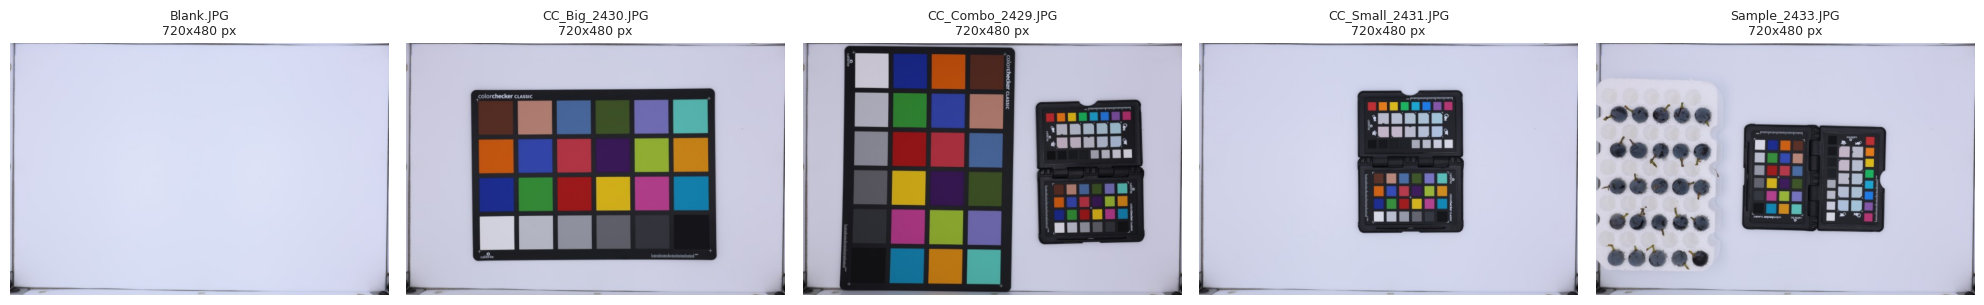

In [ ]:
D65 = "/content/cc_test_pipeline/Data/Light_Temperatures/D65"
names65 = ["Blank.JPG", "CC_Big_2430.JPG", "CC_Combo_2429.JPG", "CC_Small_2431.JPG", "Sample_2433.JPG"]
loaded = {}
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, n in zip(axes, names65):
    bgr = cv2.imread(os.path.join(D65, n))
    loaded[n] = bgr
    ax.imshow(bgr[:, :, ::-1])
    ax.set_title(f"{n}\n{bgr.shape[1]}x{bgr.shape[0]} px", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("input_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Chart detection and uncorrected baseline

The author pipeline detects the 24-patch ColorChecker with OpenCV's `cv2.mcc` `CCheckerDetector` (`key_functions.extract_color_charts`) and compares patch values against the **ColorChecker24 – After November 2014** reference from `colour-science`, chromatically adapted to D65 (`kf.adapt_chart`). Below: the detector's box overlay on the original input (drawn by the author's own routine) and the mean ΔE00 of the **uncorrected** chart patches vs the reference — the baseline the pipeline must reduce. **JA:** 著者コードによるチャート検出（枠オーバーレイ）と、補正前のΔE00ベースラインを示します。

Detected chart patches: (24, 3) | uncorrected chart vs reference:


,DE_mean,DE_max,DE_min,DE_Q1,DE_Q2,DE_Q3,DE_Q90,MSE_mean,MSE_max,MSE_min,...,MSE_Q2,MSE_Q3,MSE_Q90,MAE_mean,MAE_max,MAE_min,MAE_Q1,MAE_Q2,MAE_Q3,MAE_Q90
0,8.479,12.336,4.055,6.749,8.8,10.371,11.642,0.008,0.019,0.001,...,0.007,0.012,0.014,4.693,11.706,0.245,2.407,4.253,6.286,8.157


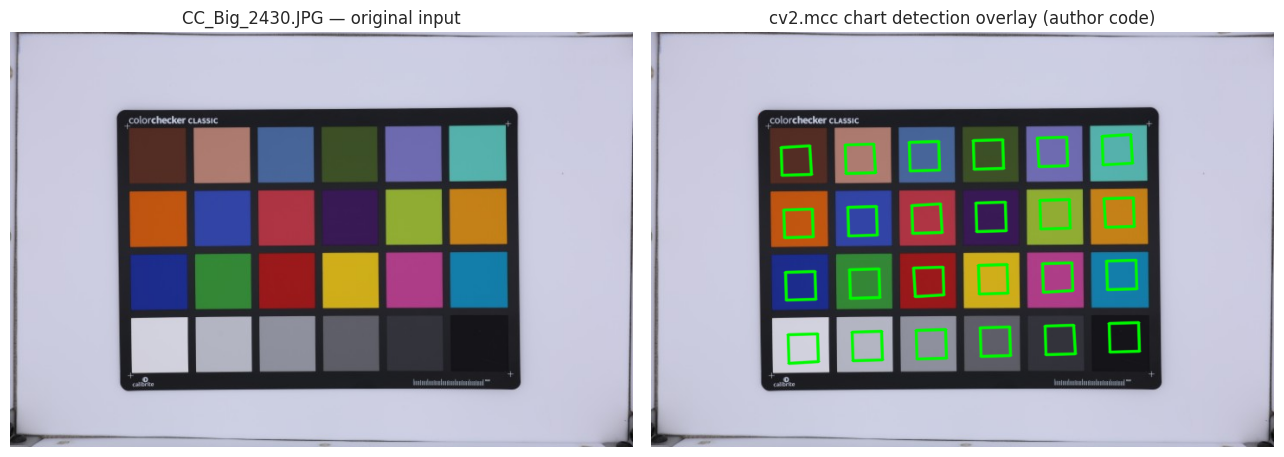

In [ ]:
import colour
ref_illuminant = kf.get_illuminant_from("D65", CMFS="CIE 1931 2 Degree Standard Observer")
ref_chart = kf.adapt_chart(kf.color_chart, ref_illuminant)
ref_rgb = np.clip(colour.XYZ_to_sRGB(
    colour.xyY_to_XYZ(list(ref_chart.data.values())),
    illuminant=ref_illuminant, apply_cctf_encoding=True), 0, 1)

img_bgr = loaded["CC_Big_2430.JPG"]
charts0, img_draw = kf.extract_color_charts(img_bgr, n_charts=1)
assert charts0, "no chart detected in CC_Big_2430.JPG"
chart0 = kf.to_float64(charts0[0])
m0 = kf.get_metrics(ref_rgb, chart0, ref_illuminant, "srgb")
print("Detected chart patches:", chart0.shape, "| uncorrected chart vs reference:")
display(m0.Data_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(img_bgr[:, :, ::-1]); axes[0].set_title("CC_Big_2430.JPG — original input"); axes[0].axis("off")
axes[1].imshow(img_draw[:, :, ::-1]); axes[1].set_title("cv2.mcc chart detection overlay (author code)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("chart_detection_overlay.png", dpi=110, bbox_inches="tight")
plt.show()

## 6. Configure the pipeline (author defaults; paper's best model)

We instantiate the author's `Config` exactly as `1.1_final_pipeline.py` does for the light-temperature experiment, with the paper's best color-mapping model: **`cc_method='ours'`, `mtd='nn'` (sklearn `MLPRegressor`), `degree=2` polynomial expansion** (paper abstract / study flow: "an NN with a second-degree polynomial expansion consistently outperformed other CM methods"). The only substitution: `FFCOptions.model_path` points at the repo's bundled `best.pt`, because the authors' config references a private `best_models/…` YOLO path that is not in the repository; `best.pt` is the repository's bundled YOLO weight used by the FFC crop step. Results are written under `/content/results_D65`. **JA:** 論文最良の「2次多項式展開＋NN」で著者のConfigを構成します。FFC用YOLO重みはリポジトリ同梱の `best.pt` を使用します（著者の `best_models/…` パスはリポジトリに存在しないため）。

In [ ]:
g_config = Config()
g_config.cc_method = "ours"          # paper's ML color mapping ('conv' = conventional CCM comparator)
g_config.update()
g_config.CC_kwargs.mtd = "nn"        # MLPRegressor on polynomial features (author OurCCOptions)
g_config.CC_kwargs.degree = 2        # second-degree polynomial expansion (paper's best model)
g_config.CC_kwargs.n_samples = 50    # sampled points per chart patch (author default)
g_config.FFC_kwargs.model_path = "/content/cc_test_pipeline/best.pt"
g_config.FFC_kwargs.manual_crop = False
g_config.do_ffc = g_config.do_gc = g_config.do_wb = g_config.do_cc = True
g_config.Saturation_kwargs.check_saturation = True
g_config.save = True
g_config.REF_ILLUMINANT = ref_illuminant
print("Config ready: FFC->Sat->GC->WB->CC(ours: nn, degree=2)")

Config ready: FFC->Sat->GC->WB->CC(ours: nn, degree=2)


## 7. Run the four-step pipeline on the D65 chart images

This is the author's `1.1_final_pipeline.py` logic, applied to one folder: each `CC_*.JPG` chart image is corrected with `Blank.JPG` as the white reference — `ColorCorrection.Run_` runs FFC → saturation check → GC → WB → CC, measuring ΔE00/MSE after every step — and the model with the lowest chart ΔE00 is kept (`CC_pred`), as in the author script. The author logger prints each stage's timing and the fitted gamma degree; the FFC cell also shows whether the YOLO crop detected the white board. **JA:** 著者の `1.1` スクリプトの処理（各チャート画像のFFC→GC→WB→CCと最良モデル選択）をそのまま実行します。

In [ ]:
def run_color_correction(image, White_Image=None, save_path=None, config=None):
    """Verbatim helper from 1.1_final_pipeline.py (author code; error log line dropped)."""
    basename = os.path.basename(image).split(".")[0]
    CC_instance = ColorCorrection()
    image_bgr = cv2.imread(image)
    assert image_bgr is not None, f"unreadable image: {image}"
    image_rgb = kf.to_float64(image_bgr[:, :, ::-1])
    white_img = cv2.imread(White_Image) if White_Image else None
    ALL_METRICS, IMAGES, err = CC_instance.Run_(Image=image_rgb, White_Image=white_img,
                                                name_=basename, config=config)
    DE = ALL_METRICS[f"{basename}_CC"]["Summary"]["DE_mean"].values[-1]
    for k, v in IMAGES.items():
        cv2.imwrite(os.path.join(save_path, f"{k}.jpg"), kf.to_uint8(v[:, :, ::-1]))
    return CC_instance, ALL_METRICS, DE, err

def run_folder(folder, save_path, config):
    """Condensed process_folder()/run_inference() from 1.1_final_pipeline.py (author logic)."""
    config = deepcopy(config)
    config.save_path = save_path
    os.makedirs(save_path, exist_ok=True)
    white = os.path.join(folder, "Blank.JPG")
    cc_imgs = sorted(glob.glob(os.path.join(folder, "CC_*.JPG")))
    sample_imgs = sorted(glob.glob(os.path.join(folder, "Sample_*.JPG")))
    results, metrics_by_image, instances = {}, {}, {}
    for i, image in enumerate(cc_imgs):
        log_(f"Running color correction on Image {i+1}/{len(cc_imgs)}: {os.path.basename(image)}", "cyan", "italic")
        inst, all_m, de, err = run_color_correction(image, White_Image=white, save_path=save_path, config=config)
        results[image], metrics_by_image[image], instances[image] = de, all_m, (inst, err)
    best_img = min(results, key=results.get)
    CC_pred = instances[best_img][0]
    log_(f"Best model from {os.path.basename(best_img)} (DE_mean={results[best_img]:.4f})", "green", "italic")
    sample_preds = {}
    for image in sample_imgs:  # author's run_inference path on the Sample image
        basename = os.path.basename(image).split(".")[0]
        out = CC_pred.Predict_Image(Image=kf.to_float64(cv2.imread(image)[:, :, ::-1]))
        cv2.imwrite(os.path.join(save_path, f"{basename}_Corrected.jpg"),
                    kf.to_uint8(np.clip(out["CC"], 0, 1)[:, :, ::-1]))
        sample_preds[basename] = out
    return results, metrics_by_image, instances, best_img, CC_pred, sample_preds

t0 = time.time()
d65_results, d65_metrics, d65_instances, d65_best, d65_pred, d65_samples = run_folder(D65, "/content/results_D65", g_config)
t_d65 = time.time() - t0
print(f"D65 folder done in {t_d65:.1f} s; best chart model from {os.path.basename(d65_best)}")

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


0: 352x512 1 Surface, 497.8ms


Speed: 13.1ms preprocess, 497.8ms inference, 33.7ms postprocess per image at shape (1, 3, 352, 512)


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


0: 352x512 1 Surface, 261.7ms


...

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


0: 352x512 1 Surface, 257.9ms


Speed: 4.0ms preprocess, 257.9ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 512)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(


D65 folder done in 322.4 s; best chart model from CC_Big_2430.JPG


## 8. Stage-wise ΔE00 results (D65, best chart image)

`Run_` measured CIEDE2000 (and MSE) after every stage (`arrange_metrics` stores a *Before* and an *After* summary row per stage). We condense the author's `Summary` frames for the best chart image into one table: mean ΔE00 **before → after** each stage (FFC, GC, WB, CC). The scientific claim under test: each step, and the pipeline overall, reduces chart ΔE00. A `None` row means that stage logged an error and was skipped (the author code catches per-stage exceptions). **JA:** 最良チャート画像の各ステージ前後の平均ΔE00を著者のメトリクスから集約します（論文の主張：各ステップで色誤差が低減）。

In [ ]:
def stage_summary(all_metrics, basename):
    rows = []
    for stage in ["FFC", "GC", "WB", "CC"]:
        key = f"{basename}_{stage}"
        if key not in all_metrics:
            rows.append({"stage": stage, "DE_mean_before": None, "DE_mean_after": None})
            continue
        s = all_metrics[key]["Summary"]  # rows ordered Before_*, After_* by arrange_metrics
        rows.append({"stage": stage,
                     "DE_mean_before": float(s["DE_mean"].values[0]),
                     "DE_mean_after": float(s["DE_mean"].values[1])})
    return pd.DataFrame(rows)

d65_base = os.path.basename(d65_best).split(".")[0]
d65_stage = stage_summary(d65_metrics[d65_best], d65_base)
print(f"Stage-wise mean CIEDE2000, best D65 chart image ({d65_base}):")
display(d65_stage)
d65_stage.to_csv("/content/d65_stage_de.csv", index=False)

Stage-wise mean CIEDE2000, best D65 chart image (CC_Big_2430):


,stage,DE_mean_before,DE_mean_after
0,FFC,8.479001,8.073569
1,GC,8.073569,4.525750
2,WB,4.525750,3.120133
3,CC,3.120133,0.264107


### ΔE00 by pipeline stage — additional visualization

A grouped bar chart of the table above (created for this notebook; not an author figure). The rightmost pair is the headline result: chart ΔE00 after the full pipeline (FFC+GC+WB+CC) vs the uncorrected input. **JA:** 各ステージのΔE00を棒グラフで可視化します（本ノートブック独自の追加図であり、論文の図ではありません）。

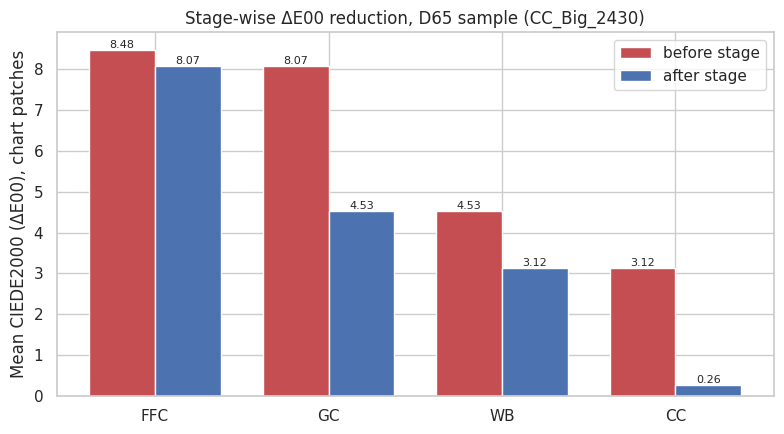

In [ ]:
plot_df = d65_stage.dropna()
x = np.arange(len(plot_df))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, plot_df["DE_mean_before"], w, label="before stage", color="#c44e52")
ax.bar(x + w/2, plot_df["DE_mean_after"], w, label="after stage", color="#4c72b0")
ax.set_xticks(x, plot_df["stage"])
ax.set_ylabel("Mean CIEDE2000 (ΔE00), chart patches")
ax.set_title(f"Stage-wise ΔE00 reduction, D65 sample ({d65_base})")
for xi, (b, a) in zip(x, zip(plot_df["DE_mean_before"], plot_df["DE_mean_after"])):
    ax.text(xi - w/2, b, f"{b:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi + w/2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig("d65_stage_de.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Apply the trained pipeline to the sample image

The best D65 model (`d65_pred`) is applied to `Sample_2433.JPG` via the author's `Predict_Image` (FFC multiplier → gamma polynomial → WB diagonal → learned NN color mapping), reproducing the paper's fruit/sample correction on the bundled sample. Original vs corrected are shown side by side (both images saved under `/content/results_D65`). **JA:** 学習済みパイプラインをサンプル画像に適用し、補正前後を並べて表示します。

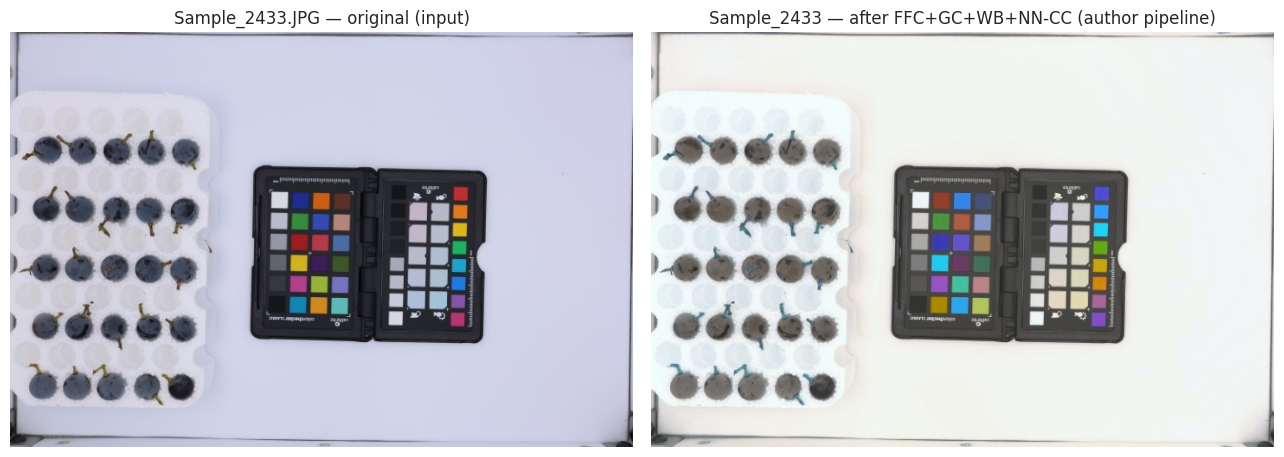

In [ ]:
sample_out = d65_samples["Sample_2433"]
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(loaded["Sample_2433.JPG"][:, :, ::-1])
axes[0].set_title("Sample_2433.JPG — original (input)"); axes[0].axis("off")
axes[1].imshow(kf.to_uint8(np.clip(sample_out["CC"], 0, 1))[:, :, ::-1])
axes[1].set_title("Sample_2433 — after FFC+GC+WB+NN-CC (author pipeline)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig("sample_before_after.png", dpi=110, bbox_inches="tight")
plt.show()

## 10. Validation metrics, 5.0-script style (CIEDE2000 / MSE)

`5.0_extract_validation.py` re-extracts the chart from each saved `*_Corrected.jpg` and computes `get_metrics` against the D65-adapted reference. We do exactly that for the color-corrected chart image (`{base}_CC.jpg` written by `Run_`), reporting the author's summary statistics plus per-patch ΔE00/MSE. **JA:** 保存済みの補正済みチャート画像から再抽出し、著者の5.0スクリプトと同じ手法でCIEDE2000/MSEを計算します。

In [ ]:
corr_path = os.path.join("/content/results_D65", f"{d65_base}_CC.jpg")
assert os.path.isfile(corr_path), corr_path
corr_bgr = cv2.imread(corr_path)
charts_c, _ = kf.extract_color_charts(corr_bgr, n_charts=1)
assert charts_c, "chart not detected in corrected image"
chart_c = kf.to_float64(charts_c[0])
m_cc = kf.get_metrics(ref_rgb, chart_c, ref_illuminant, "srgb")
print("Saved corrected image:", os.path.basename(corr_path))
display(m_cc.Data_summary.round(4))
per_patch = m_cc.Data.copy()
per_patch.index = list(ref_chart.data.keys())
display(per_patch.round(4))
per_patch.to_csv("/content/d65_cc_per_patch.csv")

Saved corrected image: CC_Big_2430_CC.jpg


,DE_mean,DE_max,DE_min,DE_Q1,DE_Q2,DE_Q3,DE_Q90,MSE_mean,MSE_max,MSE_min,...,MSE_Q2,MSE_Q3,MSE_Q90,MAE_mean,MAE_max,MAE_min,MAE_Q1,MAE_Q2,MAE_Q3,MAE_Q90
0,0.3504,1.0519,0.0617,0.1787,0.3092,0.4325,0.6902,0.0,0.0,0.0,...,0.0,0.0,0.0,0.2141,0.7816,0.0193,0.0997,0.1486,0.3321,0.39


,DeltaE,MSE,MAE
dark skin,0.7656,0.0,0.3540
light skin,0.2913,0.0,0.1488
blue sky,0.0977,0.0,0.1101
foliage,0.4097,0.0,0.0193
blue flower,0.4502,0.0,0.2352
bluish green,0.1276,0.0,0.0493
orange,0.2377,0.0,0.3306
purplish blue,0.3272,0.0,0.1847
moderate red,0.2440,0.0,0.1651
purple,0.4017,0.0,0.3588


## 11. Cross-illuminant check: the Amazon condition

The paper tunes the pipeline per illuminant and reports that correction generalizes across lighting conditions. The repo bundles a second condition, `Data/Light_Temperatures/Amazon` (a warm LED). We repeat the identical author pipeline there and compare the end-to-end chart ΔE00 (uncorrected → after the full pipeline) for the best chart image of each condition. **JA:** 同梱のもう1つの照明条件（Amazon）でも同一パイプラインを実行し、ΔE00低減を比較します。

In [ ]:
AMAZON = "/content/cc_test_pipeline/Data/Light_Temperatures/Amazon"
t0 = time.time()
amz_results, amz_metrics, amz_instances, amz_best, amz_pred, amz_samples = run_folder(
    AMAZON, "/content/results_Amazon", g_config)
t_amz = time.time() - t0
print(f"Amazon folder done in {t_amz:.1f} s; best chart model from {os.path.basename(amz_best)}")

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


0: 352x512 1 Surface, 440.3ms


Speed: 5.1ms preprocess, 440.3ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 512)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(


WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


...

WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


0: 352x512 1 Surface, 273.4ms


Speed: 4.0ms preprocess, 273.4ms inference, 1.2ms postprocess per image at shape (1, 3, 352, 512)


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (9000) reached and the optimization hasn't converged yet.
  warnings.warn(


Amazon folder done in 429.4 s; best chart model from CC_Big_2420.JPG


### D65 vs Amazon ΔE00 comparison

End-to-end effect per condition: chart ΔE00 of the raw input vs the fully corrected chart (best chart image per folder; smaller is better). **JA:** 各条件の補正前後ΔE00を比較します。

,condition,chart_image,DE00_uncorrected,DE00_after_pipeline,DE00_reduction
0,D65,CC_Big_2430,3.1201,0.2641,2.856
1,Amazon,CC_Big_2420,4.4541,0.2580,4.196


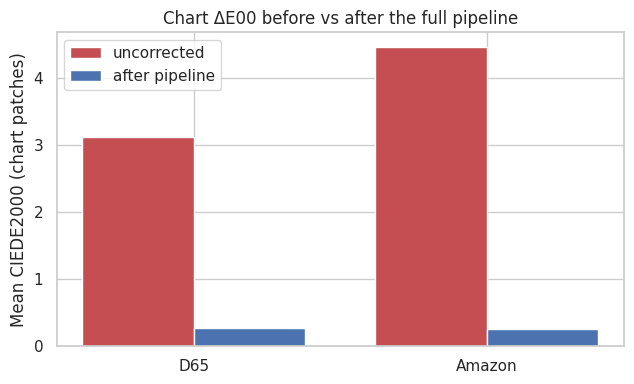

Measured wall time — D65 folder: 322s, Amazon folder: 429s


In [ ]:
amz_base = os.path.basename(amz_best).split(".")[0]
amz_stage = stage_summary(amz_metrics[amz_best], amz_base)
cmp_df = pd.DataFrame([
    {"condition": "D65", "chart_image": d65_base,
     "DE00_uncorrected": d65_stage.loc[d65_stage.stage == "CC", "DE_mean_before"].iloc[0],
     "DE00_after_pipeline": d65_stage.loc[d65_stage.stage == "CC", "DE_mean_after"].iloc[0]},
    {"condition": "Amazon", "chart_image": amz_base,
     "DE00_uncorrected": amz_stage.loc[amz_stage.stage == "CC", "DE_mean_before"].iloc[0],
     "DE00_after_pipeline": amz_stage.loc[amz_stage.stage == "CC", "DE_mean_after"].iloc[0]},
])
cmp_df["DE00_reduction"] = cmp_df["DE00_uncorrected"] - cmp_df["DE00_after_pipeline"]
display(cmp_df.round(4))
cmp_df.to_csv("/content/condition_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(2)
w = 0.38
ax.bar(x - w/2, cmp_df["DE00_uncorrected"], w, label="uncorrected", color="#c44e52")
ax.bar(x + w/2, cmp_df["DE00_after_pipeline"], w, label="after pipeline", color="#4c72b0")
ax.set_xticks(x, cmp_df["condition"])
ax.set_ylabel("Mean CIEDE2000 (chart patches)")
ax.set_title("Chart ΔE00 before vs after the full pipeline")
ax.legend()
plt.tight_layout()
plt.savefig("condition_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Measured wall time — D65 folder: {t_d65:.0f}s, Amazon folder: {t_amz:.0f}s")

## 12. Interpretation, validation record, and references

**Observed in this run:** the stage table in §8, the per-patch validation in §10 and the comparison in §11 are outputs of the author's own metric code executed on the bundled samples in this fresh runtime (values printed above are from the actual run). The paper's directional claim — chart ΔE00 drops after the correction stages — can be checked directly against those printed numbers. A single-example run does **not** verify the paper's dataset-level results.

**Differences from the paper (documented adaptations):** (1) bundled samples only (2 illuminants × 1 chart-size set) instead of the full benchmark; (2) `best.pt` used for the FFC crop because the authors' `best_models/…` path is not in the repository; (3) the `statsmodels` statistical analyses and the light-position / wall-material / saturation experiments are out of scope; (4) the paper's exact numeric tables could not be compared because the publisher blocked agent full-text access (HTTP 403) and the deposited 958 MB dataset was not fetched here.

**Validation record:** executed on Colab (see header/runtime report for hardware), all cells top-to-bottom in a fresh runtime; author code at commit `42bb4aa11a5d6bdf09e1f9dfac8c184f38e7dc52`; sample bytes verified (JPEG magic, `best.pt` size).

**References:** paper DOI [10.1002/ppj2.70067](https://doi.org/10.1002/ppj2.70067); code [cc_test_pipeline@42bb4aa1](https://github.com/collinswakholi/cc_test_pipeline); full dataset [HF CollinsW/ColorCorrectionPipeline_Dataset](https://huggingface.co/datasets/CollinsW/ColorCorrectionPipeline_Dataset) / [NAL ADC 10.15482/USDA.ADC/31256776](https://doi.org/10.15482/USDA.ADC/31256776).

**JA（結果の解釈）：** §8・§10・§11の表と図は、著者自身の評価コードを同梱サンプルに対して実行した実際の出力です。補正後にチャートΔE00が低下すること（パイプラインの主張）を数値で確認できます。ただし単一サンプルの実行であり、論文のデータセット規模の精度や `statsmodels` による統計検定は範囲外です。出版全文はエージェントに対してHTTP 403でブロックされたため、論文の数値表との逐一比較は行っていません。